# Model Evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.calibration import calibration_curve, CalibrationDisplay #%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Cleaning

Load the raw ball-by-ball IPL CSV, filter to 2nd innings only, then drop nulls and duplicates.

In [2]:
# Load raw data
CSV_PATH = 'IPL_Data.csv'
raw = pd.read_csv(CSV_PATH, low_memory=False)
print('Raw shape:', raw.shape)

# Keep 2nd innings only
inning2 = raw[raw['inning'] == 2].copy()
inning2 = inning2.dropna(subset=['batting_team','bowling_team','venue','target_runs','winner'])
inning2 = inning2.drop_duplicates()
print('Inning-2 shape after cleaning:', inning2.shape)
inning2.head(3)

Raw shape: (260920, 44)
Inning-2 shape after cleaning: (125741, 44)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
124,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,R Dravid,AB Dinda,W Jaffer,1,...,Normal,Asad Rauf,RE Koertzen,True,1,0.1,0.1,1,58,1
125,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,2,W Jaffer,AB Dinda,R Dravid,0,...,Normal,Asad Rauf,RE Koertzen,False,1,0.2,0.1,1,58,1
126,335982,2,Royal Challengers Bangalore,Kolkata Knight Riders,0,3,W Jaffer,AB Dinda,R Dravid,0,...,Normal,Asad Rauf,RE Koertzen,True,2,0.3,0.2,1,58,1


## 2. Feature Engineering

Aggregate ball-by-ball rows into **per-over snapshots** for each match, then compute in-game run rates and the binary win label.

In [3]:
# Aggregate to match × over level
grp = (
    inning2
    .groupby(['match_id', 'over'])
    .agg(
        batting_team  = ('batting_team', 'first'),
        bowling_team  = ('bowling_team', 'first'),
        venue         = ('venue',        'first'),
        target_runs   = ('target_runs',  'first'),
        over_runs     = ('total_runs',   'sum'),
        over_wickets  = ('is_wicket',    'sum'),
        winner        = ('winner',       'first'),
        legal_balls   = ('is_legal',     'sum'),
    )
    .reset_index()
    .sort_values(['match_id', 'over'])
)

# Cumulative totals per match
grp['cum_runs']    = grp.groupby('match_id')['over_runs'].cumsum()
grp['cum_wickets'] = grp.groupby('match_id')['over_wickets'].cumsum()
grp['cum_balls']   = grp.groupby('match_id')['legal_balls'].cumsum()

# Run-rate features
grp['current_run_rate']  = (grp['cum_runs'] / grp['cum_balls']) * 6
grp['balls_remaining']   = 120 - grp['cum_balls']
grp['runs_needed']       = grp['target_runs'] - grp['cum_runs']
grp['required_run_rate'] = (grp['runs_needed'] / grp['balls_remaining'].replace(0, np.nan)) * 6

# Binary target: did batting team win?
grp['result'] = (grp['batting_team'] == grp['winner']).astype(int)

# Keep only mid-game valid snapshots
df = grp[
    (grp['balls_remaining'] > 0) &
    (grp['cum_balls']       > 0) &
    (grp['target_runs']     > 0) &
    (grp['cum_wickets']    <= 10)
].dropna(subset=['required_run_rate', 'current_run_rate', 'target_runs']).copy()

print('Snapshot dataset shape:', df.shape)
print('Win rate: {:.1%}'.format(df['result'].mean()))
df[['batting_team','bowling_team','venue','cum_runs','cum_wickets',
    'current_run_rate','required_run_rate','result']].head()

Snapshot dataset shape: (20045, 18)
Win rate: 53.2%


,batting_team,bowling_team,venue,cum_runs,cum_wickets,current_run_rate,required_run_rate,result
0,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,4,0,4.0,11.526316,0
1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,9,1,4.5,11.888889,0
2,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,12,2,4.0,12.411765,0
3,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,16,2,4.0,12.937500,0
4,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,24,3,4.8,13.266667,0


In [4]:
# Add run_rate_diff (mirrors original notebook)
df['run_rate_diff'] = df['required_run_rate'] - df['current_run_rate']

# Select modelling columns

feature_cols = [
    'batting_team', 'bowling_team', 'venue',
    'cum_runs', 'cum_wickets', 'current_run_rate',
    'required_run_rate', 'run_rate_diff', 'balls_remaining',
]

X = df[feature_cols]
y = df['result']
print('Features:', X.columns.tolist())
X.head()

Features: ['batting_team', 'bowling_team', 'venue', 'cum_runs', 'cum_wickets', 'current_run_rate', 'required_run_rate', 'run_rate_diff', 'balls_remaining']


,batting_team,bowling_team,venue,cum_runs,cum_wickets,current_run_rate,required_run_rate,run_rate_diff,balls_remaining
0,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,4,0,4.0,11.526316,7.526316,114
1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,9,1,4.5,11.888889,7.388889,108
2,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,12,2,4.0,12.411765,8.411765,102
3,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,16,2,4.0,12.937500,8.937500,96
4,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,24,3,4.8,13.266667,8.466667,90


## 3. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train samples: {len(X_train)}')
print(f'Test  samples: {len(X_test)}')

Train samples: 16036
Test  samples: 4009


## 4. Model Training

In [6]:
cat_features = ['batting_team', 'bowling_team', 'venue']

encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('encoder', encoder),
    ('clf', LogisticRegression(max_iter=1000, C=1.0))
])

pipeline.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 5. Evaluation Metrics

In [7]:
y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC:  {roc_auc:.4f}')

Accuracy: 0.8154
ROC AUC:  0.9028


### Confusion Matrix

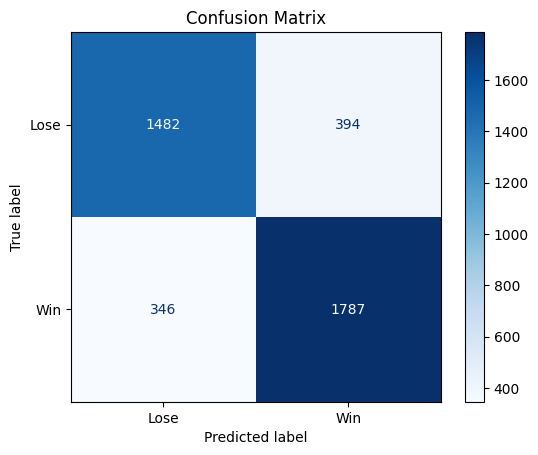

In [8]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lose', 'Win'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### Calibration Curve

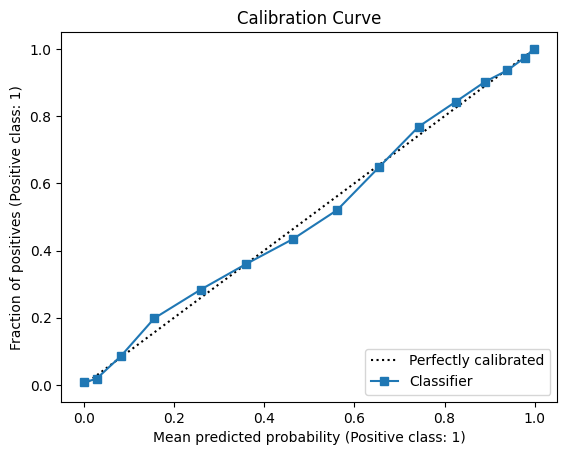

In [9]:
disp = CalibrationDisplay.from_predictions(
    y_test,
    y_pred_proba,
    n_bins=15,
    strategy='quantile'
)
plt.title('Calibration Curve')
plt.show()

### ROC Curve

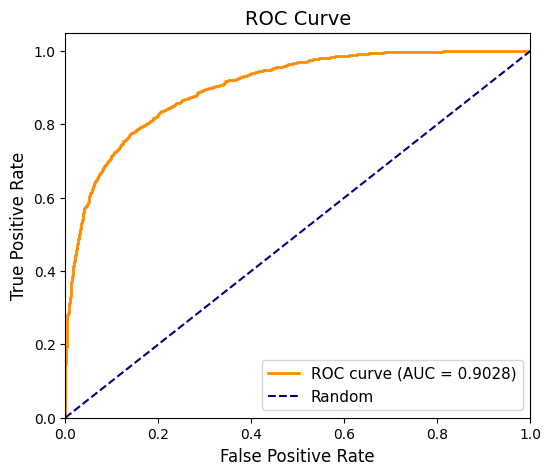

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color="darkorange", lw=2,
        label=f"ROC curve (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1.5,
        linestyle="--", label="Random")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve", fontsize=14)
ax.legend(loc="lower right", fontsize=11)

plt.show()